In [1]:
!pip install torch-ema

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [2]:
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import AdamW
import torchvision.transforms as T
import torchvision.transforms.functional as F
from scipy.ndimage import gaussian_filter, median_filter
import torch.nn.functional as F_nn
import random
from torch_ema import ExponentialMovingAverage

from PIL import Image
from tqdm import tqdm

import time
import os

import matplotlib.pyplot as plt
import pandas as pd
import timm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_epoch_head = 10       # Train classifier head first
num_epoch_finetune = 40  # Fine-tune full model

def deterministic_transform(color_img, depth_img, output_size=380, max_depth=10.0):
    color_img = F.resize(color_img, (output_size, output_size), interpolation=Image.BILINEAR)
    depth_img = F.resize(depth_img, (output_size, output_size), interpolation=Image.NEAREST)

    # Convert to tensor
    color_tensor = F.to_tensor(color_img)
    color_tensor = F.normalize(color_tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

    depth_np = np.array(depth_img).astype(np.float32) / 1000.0
    depth_tensor = torch.from_numpy(np.clip(depth_np, 0, max_depth)).unsqueeze(0)

    return color_tensor, depth_tensor

def paired_transform(color_img, depth_img, output_size=380):
    """
    Geometric augmentation on RGB + depth, but **does not modify depth values**.
    """
    # Random horizontal flip
    if random.random() > 0.5:
        color_img = F.hflip(color_img)
        depth_img = F.hflip(depth_img)

    # Random rotation
    angle = random.uniform(-15, 15)
    color_img = F.rotate(color_img, angle, interpolation=Image.BILINEAR)
    depth_img = F.rotate(depth_img, angle, interpolation=Image.NEAREST)

    # Random resized crop
    i, j, h, w = T.RandomResizedCrop.get_params(
        color_img, scale=(0.8, 1.0), ratio=(1.0, 1.0)
    )
    color_img = F.resized_crop(color_img, i, j, h, w, size=(output_size, output_size))
    depth_img = F.resized_crop(depth_img, i, j, h, w, size=(output_size, output_size))

    # Optional color jitter (RGB only)
    color_jitter = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
    color_img = color_jitter(color_img)

    # Convert RGB to tensor and normalize
    color_tensor = F.to_tensor(color_img)
    color_tensor = F.normalize(color_tensor, mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])

    # Convert depth to tensor (meters) **without modifying values**
    depth_np = np.array(depth_img).astype(np.float32) / 1000.0
    depth_tensor = torch.from_numpy(np.clip(depth_np, 0, 10.0)).unsqueeze(0)

    return color_tensor, depth_tensor
    

class DepthDataset(Dataset):
    def __init__(self, data_dir, paired_transform=None, deterministic_transform=None, max_depth=10.0):
        """
        Args:
            data_dir (str): Path to folder containing 'colors/' and 'depths/' subfolders.
            paired_transform (callable, optional): Function to apply same geometric transform to both RGB and depth.
            max_depth (float): Maximum depth value to scale depth maps (in meters).
        """
        self.data_dir = data_dir
        self.paired_transform = paired_transform
        self.deterministic_transform = deterministic_transform
        self.max_depth = max_depth

        # Paths to color and depth folders
        self.color_dir = os.path.join(data_dir, "colors")
        self.depth_dir = os.path.join(data_dir, "depths")

        # List all RGB color images
        self.color_files = sorted([f for f in os.listdir(self.color_dir) if f.endswith("_colors.png")])
        
        self.current_epoch = num_epoch_head
        self.total_epochs = num_epoch_finetune  # default, can be updated

    def __len__(self):
        return len(self.color_files)

    def __getitem__(self, idx):
        # Load RGB image
        color_path = os.path.join(self.color_dir, self.color_files[idx])
        color_img = Image.open(color_path).convert("RGB")

        # Load corresponding depth image
        depth_file = self.color_files[idx].replace("_colors.png", "_depth.png")
        depth_path = os.path.join(self.depth_dir, depth_file)
        depth_img = Image.open(depth_path)

        # Apply paired transform if provided
        if self.paired_transform:
            color_tensor, depth_tensor = self.paired_transform(color_img, depth_img)
        elif self.deterministic_transform:
            color_tensor, depth_tensor = self.deterministic_transform(color_img, depth_img)
        else:
            raise ValueError("must have transformation type")

        return color_tensor, depth_tensor

    def set_epoch(self, epoch, total_epochs=None):
        """Update current epoch for curriculum depth augmentations"""
        self.current_epoch = epoch
        if total_epochs is not None:
            self.total_epochs = total_epochs


class DepthModel(nn.Module):
    def __init__(self, backbone_name='efficientnet_b4', pretrained=True):
        super().__init__()
        
        # --------------------------
        # Encoder: pretrained CNN
        # --------------------------
        # Use features_only=True to get intermediate feature maps for decoder
        self.encoder = timm.create_model(backbone_name, pretrained=pretrained, features_only=True)
        
        # Channels of encoder feature maps at each stage
        encoder_channels = self.encoder.feature_info.channels()  # e.g., [48, 56, 160, 448]
        last_ch = encoder_channels[-1]

        # --------------------------
        # Simple decoder: upsample to original resolution
        # --------------------------
        self.decoder = nn.Sequential(
            nn.Conv2d(last_ch, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(64, 1, kernel_size=3, padding=1)  # Output: single-channel depth map
        )

    def forward(self, x):
        # Encoder forward: returns list of feature maps at different stages
        input_size = x.shape[2:]  # height and width of **original input image**
        
        features = self.encoder(x)
        x_enc = features[-1]
        
        depth = self.decoder(x_enc)
        depth = F_nn.interpolate(depth, size=input_size, mode='bilinear', align_corners=False)
        
        return depth
        
# -------------------------
# Optimize for RMSE MAE - split between both
# -------------------------
class RMSE_MAE_Loss(nn.Module):
    def __init__(self, alpha=0.5):
        """
        alpha: weight for RMSE (0-1).
        (1-alpha) is weight for MAE.
        """
        super().__init__()
        self.alpha = alpha

    def forward(self, pred, target):
        mask = target > 0  # ignore invalid depths
        pred, target = pred[mask], target[mask]

        mse = torch.mean((pred - target) ** 2)
        rmse = torch.sqrt(mse + 1e-6)
        mae = torch.mean(torch.abs(pred - target))

        return self.alpha * rmse + (1 - self.alpha) * mae

def edge_aware_smoothness_loss(depth, image):
    """
    Edge-aware depth smoothness loss (used in Monodepth/others).
    depth: (B,1,H,W)
    image: (B,3,H,W) normalized RGB

    Returns: scalar loss
    """
    # Depth gradients
    depth_dx = depth[:, :, :, 1:] - depth[:, :, :, :-1]
    depth_dy = depth[:, :, 1:, :] - depth[:, :, :-1, :]

    # Image gradients (for edge weighting)
    image_dx = torch.mean(torch.abs(image[:, :, :, 1:] - image[:, :, :, :-1]), 1, keepdim=True)
    image_dy = torch.mean(torch.abs(image[:, :, 1:, :] - image[:, :, :-1, :]), 1, keepdim=True)

    # Weight depth gradients by image gradients (edges preserved)
    depth_dx *= torch.exp(-image_dx)
    depth_dy *= torch.exp(-image_dy)

    return depth_dx.abs().mean() + depth_dy.abs().mean()


# -------------------------
# Optimizer + Cosine + Warmup
# -------------------------
def get_optimizer_scheduler_multilr(model, train_loader, num_epochs, 
                                    lr_decoder=3e-4, lr_encoder=1e-4, weight_decay=1e-2, warmup_frac=0.05):
    # Separate parameter groups
    encoder_params = []
    decoder_params = []
    for name, param in model.named_parameters():
        if "encoder" in name:
            encoder_params.append(param)
        else:
            decoder_params.append(param)

    optimizer = torch.optim.AdamW([
        {'params': decoder_params, 'lr': lr_decoder},
        {'params': encoder_params, 'lr': lr_encoder}
    ], weight_decay=weight_decay)

    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * warmup_frac)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler, total_steps

# -------------------------
# EMA wrapper
# -------------------------
def get_ema(model, decay=0.999):
    return ExponentialMovingAverage(model.parameters(), decay=decay)


def post_process_depth(pred_batch, median_size=3, gaussian_sigma=1.0):
    """
    pred_batch: torch.Tensor of shape (B, 1, H, W)
    Returns: post-processed torch.Tensor of same shape
    """
    pred_batch_np = pred_batch.squeeze(1).cpu().numpy()  # (B, H, W)
    processed = []
    for i in range(pred_batch_np.shape[0]):
        d = pred_batch_np[i]
        d_med = median_filter(d, size=median_size)
        d_smooth = gaussian_filter(d_med, sigma=gaussian_sigma)
        processed.append(d_smooth)
    processed = np.stack(processed, axis=0)
    return torch.from_numpy(processed).unsqueeze(1).to(pred_batch.device)



Using device: cuda


In [3]:


def train_depth_model_postproc(model, train_dataset, train_loader, val_loader, 
                               epochs, freeze_encoder=True, epoch_offset=0, 
                               total_epochs=50, model_path="depth_model.pth", 
                               best_val_loss=float("inf"), lambda_smooth=0.01):

    criterion = RMSE_MAE_Loss(alpha=0.5)
    scaler = torch.amp.GradScaler()

    # Freeze encoder if needed
    if freeze_encoder:
        for p in model.encoder.parameters():
            p.requires_grad = False

    optimizer, scheduler, total_steps = get_optimizer_scheduler_multilr(model, train_loader, epochs,
                                                                        lr_decoder=3e-4,
                                                                        lr_encoder=1e-4)
    ema = get_ema(model)

    global_step = 0

    for epoch in range(epochs):
        train_dataset.set_epoch(epoch + epoch_offset, total_epochs=total_epochs)
        model.train()
        train_loss = 0.0

        for images, depths in tqdm(train_loader):
            images, depths = images.to(device), depths.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                base_loss = criterion(outputs, depths)
                smooth_loss = edge_aware_smoothness_loss(outputs, images)
                loss = base_loss + lambda_smooth * smooth_loss

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ema.update()
            global_step += 1

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        # --------------------------
        # Validation with EMA + [No post-processing]
        # --------------------------
        ema.store()
        ema.copy_to()
        model.eval()
        val_loss, val_mae, n_samples = 0.0, 0.0, 0

        with torch.no_grad():
            for images, depths in val_loader:
                images, depths = images.to(device), depths.to(device)
                outputs = model(images)

                # # Post-processing: median + Gaussian smoothing
                # outputs_pp = post_process_depth(outputs, median_size=3, gaussian_sigma=1.0)

                # Compute loss on processed predictions
                loss = criterion(outputs, depths)
                val_loss += loss.item() * images.size(0)

                # Compute MAE
                mask = depths > 0
                mae = torch.abs(outputs - depths)
                mae = mae[mask].mean().item()
                val_mae += mae * images.size(0)
                n_samples += images.size(0)

        val_loss /= n_samples
        val_mae /= n_samples
        rmse = np.sqrt(val_loss)
        ema.restore()

        print(f"Epoch {epoch+1+epoch_offset}/{total_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"RMSE: {rmse:.4f} | MAE: {val_mae:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path)
            print("✅ Best model saved.")

    return best_val_loss



# --------------------------
# Run training
# --------------------------


# --------------------------
# Device
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------
# Model
# --------------------------
model = DepthModel().to(device)


# --------------------------
# Datasets & Loaders
# --------------------------
train_folder = "/kaggle/input/nyu-depth-split-dataset/nyu_split/train"
valid_folder = "/kaggle/input/nyu-depth-split-dataset/nyu_split/val"
max_depth = 10

MODEL_PATH = "/kaggle/working/depth_predictor.pth"

train_dataset = DepthDataset(train_folder, paired_transform = paired_transform, max_depth = max_depth)
val_dataset = DepthDataset(valid_folder, deterministic_transform = deterministic_transform, max_depth = max_depth)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)



# --------------------------
# Training Parameters
# --------------------------



encoder_layers = [
    nn.Sequential(model.encoder.conv_stem, model.encoder.bn1),  # stem
    model.encoder.blocks[0],  # early MBConv blocks
    model.encoder.blocks[1],
    model.encoder.blocks[2],
    model.encoder.blocks[3],
    model.encoder.blocks[4],
    model.encoder.blocks[5],
    model.encoder.blocks[6]   # last MBConv blocks (includes what would have been conv_head)
]


# Freeze everything initially
for param in model.encoder.parameters():
    param.requires_grad = False

# Train decoder first
best_val_loss = train_depth_model_postproc(
    model, train_dataset, train_loader, val_loader,
    epochs=num_epoch_head,
    freeze_encoder=True,
    epoch_offset=0,
    total_epochs=(num_epoch_head + num_epoch_finetune),
    model_path=MODEL_PATH
)

# Gradually unfreeze encoder groups
for i, layer_group in enumerate(reversed(encoder_layers)):  # start from last
    for param in layer_group.parameters():
        param.requires_grad = True
    
    # Fine-tune for a fraction of total finetune epochs
    best_val_loss = train_depth_model_postproc(
        model, train_dataset, train_loader, val_loader,
        epochs=num_epoch_finetune // len(encoder_layers),
        freeze_encoder=False,
        epoch_offset=num_epoch_head + i*(num_epoch_finetune // len(encoder_layers)),
        total_epochs=(num_epoch_head + num_epoch_finetune),
        model_path=f"depth_model_stage{i+1}.pth",
        best_val_loss=best_val_loss
    )

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

100%|██████████| 37/37 [00:23<00:00,  1.57it/s]


Epoch 1/50 | Train Loss: 1.6215 | Val Loss: 0.9673 | RMSE: 0.9835 | MAE: 0.8369
✅ Best model saved.


100%|██████████| 37/37 [00:15<00:00,  2.40it/s]


Epoch 2/50 | Train Loss: 0.9543 | Val Loss: 0.8657 | RMSE: 0.9304 | MAE: 0.7450
✅ Best model saved.


...

Epoch 48/50 | Train Loss: 0.5421 | Val Loss: 0.6374 | RMSE: 0.7984 | MAE: 0.5354
✅ Best model saved.


100%|██████████| 37/37 [00:16<00:00,  2.23it/s]


Epoch 49/50 | Train Loss: 0.5174 | Val Loss: 0.6416 | RMSE: 0.8010 | MAE: 0.5387


100%|██████████| 37/37 [00:16<00:00,  2.19it/s]


Epoch 50/50 | Train Loss: 0.5027 | Val Loss: 0.6338 | RMSE: 0.7961 | MAE: 0.5316
✅ Best model saved.


Using device: cuda


Evaluating on test set: 100%|██████████| 21/21 [00:19<00:00,  1.09it/s]


✅ Test Results -> MSE: 0.8017, RMSE: 0.8954 m, MAE: 0.6325 m


Visualizing predictions: 100%|██████████| 5/5 [00:00<00:00, 11.18it/s]


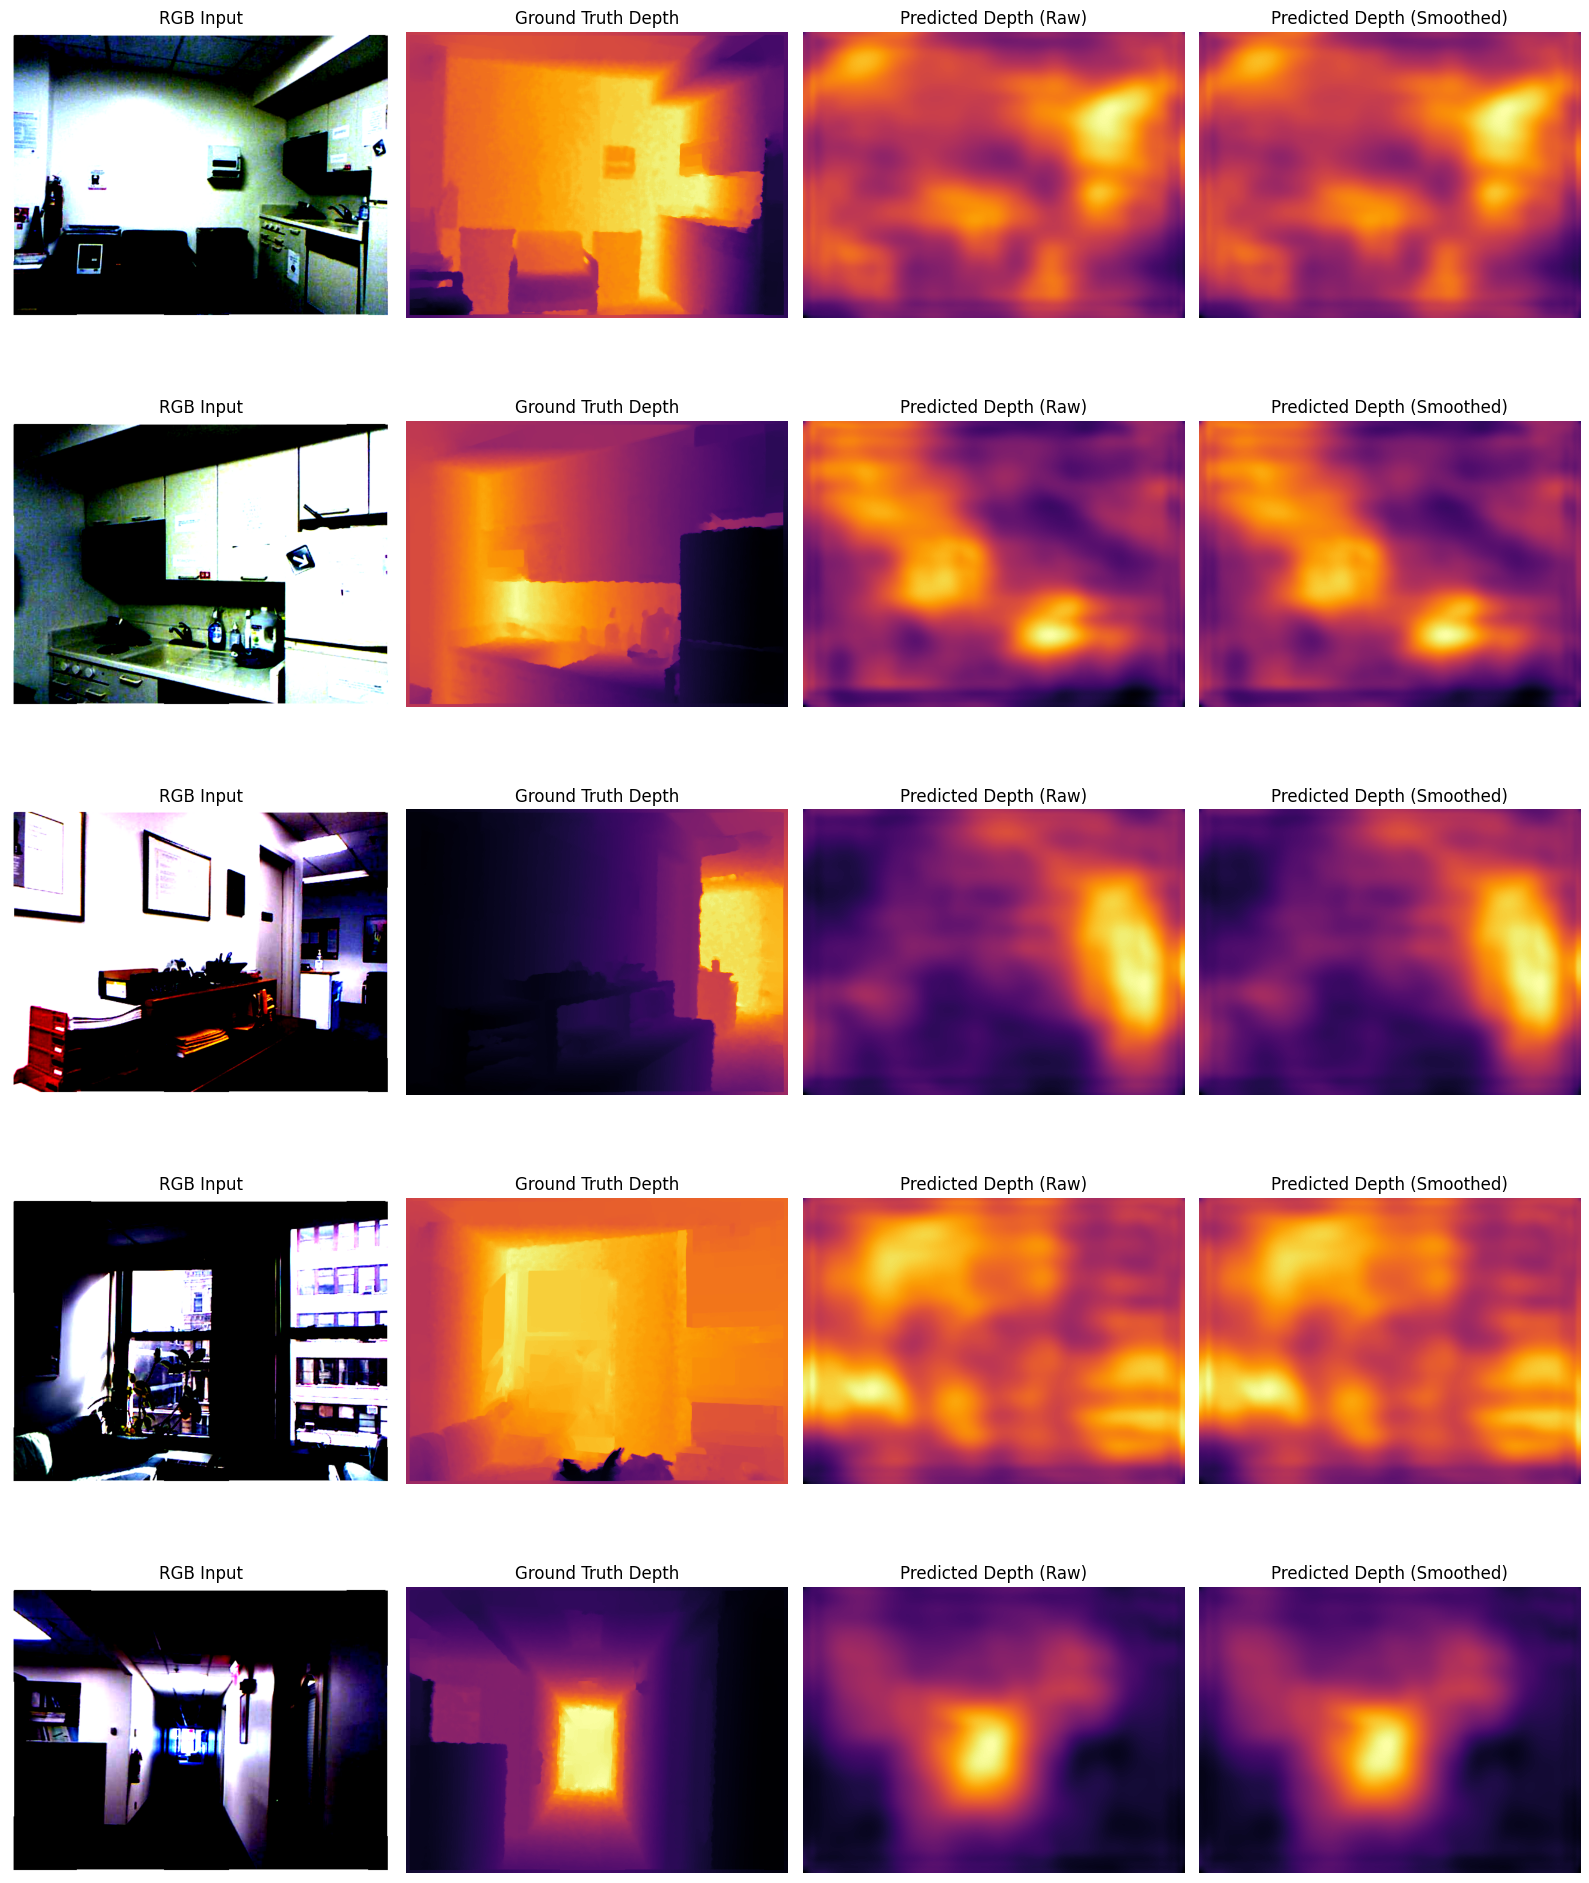

In [4]:
# --------------------------
# Testing / Inference
# --------------------------
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import cv2
from scipy.ndimage import median_filter, gaussian_filter

def post_process_depth(depth_map, median_size=3, gaussian_sigma=1.0):
    """
    Apply median filter + Gaussian smoothing to a depth prediction.
    depth_map: numpy array (H, W)
    """
    depth_map = median_filter(depth_map, size=median_size)
    depth_map = gaussian_filter(depth_map, sigma=gaussian_sigma)
    return depth_map

def deterministic_transform(color_img, depth_img, output_size=224, max_depth=10.0):
    """
    Deterministic preprocessing for inference:
    - Resize/crop to fixed size
    - Convert to tensors
    - Normalize RGB
    - Depth scaled to meters, clamped
    """
    # Resize both RGB and depth to output_size x output_size
    color_img = F.resize(color_img, (output_size, output_size), interpolation=Image.BILINEAR)
    depth_img = F.resize(depth_img, (output_size, output_size), interpolation=Image.NEAREST)

    # Convert RGB to tensor and normalize
    color_tensor = F.to_tensor(color_img)
    color_tensor = F.normalize(color_tensor, mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])

    # Convert depth to tensor and scale to meters
    depth_np = np.array(depth_img).astype(np.float32) / 1000.0  # mm -> meters
    depth_tensor = torch.from_numpy(np.clip(depth_np, 0, max_depth)).unsqueeze(0)

    return color_tensor, depth_tensor

class TestDepthDataset(Dataset):
    def __init__(self, data_dir, transform=None, max_depth=10.0):
        """
        Args:
            data_dir (str): Path to folder containing 'colors/' and 'depths/' subfolders.
            transform (callable, optional): Deterministic transform for RGB & depth
            max_depth (float): Maximum depth value to clamp
        """
        self.data_dir = data_dir
        self.transform = transform
        self.max_depth = max_depth

        self.color_dir = os.path.join(data_dir, "colors")
        self.depth_dir = os.path.join(data_dir, "depths")

        self.color_files = sorted([f for f in os.listdir(self.color_dir) if f.endswith("_colors.png")])

    def __len__(self):
        return len(self.color_files)

    def __getitem__(self, idx):
        color_path = os.path.join(self.color_dir, self.color_files[idx])
        depth_file = self.color_files[idx].replace("_colors.png", "_depth.png")
        depth_path = os.path.join(self.depth_dir, depth_file)

        color_img = Image.open(color_path).convert("RGB")
        depth_img = Image.open(depth_path)

        if self.transform:
            color_tensor, depth_tensor = self.transform(color_img, depth_img)
        else:
            # fallback: basic deterministic preprocessing
            color_tensor = T.ToTensor()(color_img)
            color_tensor = T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])(color_tensor)

            depth_np = np.array(depth_img).astype(np.float32) / 1000.0
            depth_tensor = torch.from_numpy(np.clip(depth_np, 0, self.max_depth)).unsqueeze(0)

        return color_tensor, depth_tensor


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------------
# Test Dataset & DataLoader
# --------------------------
test_folder = "/kaggle/input/nyu-test-colors-depths/nyu2_test_colors_depths"
test_dataset = TestDepthDataset(test_folder, max_depth=10.0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Load trained model
test_model = DepthModel().to(device)
test_model.load_state_dict(torch.load(
    "/kaggle/input/model-edge-aware-smoothness-loss/pytorch/default/1/depth_model_stage1 (2).pth", 
    map_location=device
))
test_model.eval()

# Loss function for evaluation
criterion = nn.MSELoss()

# --------------------------
# Evaluation with tqdm
# --------------------------
val_loss, val_mae = 0.0, 0.0
with torch.no_grad():
    for images, depths in tqdm(test_loader, desc="Evaluating on test set"):
        images, depths = images.to(device), depths.to(device)
        outputs = test_model(images)

        # Loss metrics
        mse_loss = criterion(outputs, depths)
        mae_loss = torch.mean(torch.abs(outputs - depths))

        val_loss += mse_loss.item() * images.size(0)
        val_mae += mae_loss.item() * images.size(0)

val_loss /= len(test_loader.dataset)
val_mae /= len(test_loader.dataset)
val_rmse = np.sqrt(val_loss)

print(f"✅ Test Results -> MSE: {val_loss:.4f}, RMSE: {val_rmse:.4f} m, MAE: {val_mae:.4f} m")

# --------------------------
# Visualization
# --------------------------
def show_predictions(model, dataset, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

    for i in tqdm(range(num_samples), desc="Visualizing predictions"):
        color, depth_gt = dataset[i]
        color_batch = color.unsqueeze(0).to(device)

        with torch.no_grad():
            depth_pred = model(color_batch).cpu().squeeze().numpy()

        # Apply post-processing (median + Gaussian)
        depth_pred_pp = post_process_depth(depth_pred, median_size=3, gaussian_sigma=1.0)

        depth_gt = depth_gt.squeeze().numpy()

        # Plot RGB Input
        axes[i, 0].imshow(np.transpose(color.numpy(), (1, 2, 0)))
        axes[i, 0].set_title("RGB Input")
        axes[i, 0].axis("off")

        # Plot Ground Truth Depth
        axes[i, 1].imshow(depth_gt, cmap="inferno")
        axes[i, 1].set_title("Ground Truth Depth")
        axes[i, 1].axis("off")

        # Plot Raw Predicted Depth
        axes[i, 2].imshow(depth_pred, cmap="inferno")
        axes[i, 2].set_title("Predicted Depth (Raw)")
        axes[i, 2].axis("off")

        # Plot Post-Processed Depth
        axes[i, 3].imshow(depth_pred_pp, cmap="inferno")
        axes[i, 3].set_title("Predicted Depth (Smoothed)")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

# Visualize predictions from test set
show_predictions(test_model, test_dataset, num_samples=5)